# High pLLPS Protein Interaction Analysis

This notebook analyzes whether high pLLPS proteins preferentially interact with other high pLLPS proteins.

**Workflow:**
1. Filter high pLLPS entries from the dataset
2. Fetch interaction partners from STRING database
3. Match interactors against the dataset to get their pLLPS scores
4. Test for high-high vs high-low over-representation

In [10]:
import pandas as pd
import numpy as np
import requests
import time
from scipy import stats
import sys
import os

# Add current directory to path to import local module
sys.path.append(os.getcwd())

# Import from master functions file
import llps_functions as lf


## Step 1: Load Data and Filter High pLLPS Proteins

In [11]:
# Load and classify the dataset
df = lf.load_and_classify_data('Human Phase separation data.xlsx', high_threshold=0.7, low_threshold=0.4)
df.head()

Total proteins: 20366
p(LLPS) range: 0.060 - 1.000
Protein Classification Counts:
pLLPS_class
Low       10663
High       6657
Medium     3046
Name: count, dtype: int64

High: >=0.7
Medium: 0.4-0.7
Low: <0.4


,Entry,Entry name,Protein names,p(LLPS),n(DPR=> 25),Organism,Length,Function [CC],Subcellular location [CC],Involvement in disease,Cross-reference (PDB),pLLPS_class
0,Q9Y6V0,PCLO_HUMAN,Protein piccolo (Aczonin),1.0,21,Homo sapiens (Human),5142.0,Scaffold protein of the presynaptic cytomatri...,"Cell junction, synapse, presynaptic active zo...",Pontocerebellar hypoplasia 3 (PCH3) [MIM:6080...,1UJD;,High
1,Q9Y566,SHAN1_HUMAN,SH3 and multiple ankyrin repeat domains protei...,1.0,8,Homo sapiens (Human),2161.0,Seems to be an adapter protein in the postsyn...,"Cytoplasm {ECO:0000250}. Cell junction, synap...",NaN,6CPI;,High
2,Q9Y520,PRC2C_HUMAN,Protein PRRC2C (BAT2 domain-containing protein...,1.0,17,Homo sapiens (Human),2896.0,Required for efficient formation of stress gr...,"Cytoplasm, Stress granule {ECO:0000305|PubMed...",NaN,NaN,High
3,Q9Y4H2,IRS2_HUMAN,Insulin receptor substrate 2 (IRS-2),1.0,9,Homo sapiens (Human),1338.0,May mediate the control of various cellular p...,"Cytoplasm, cytosol {ECO:0000250}.",NaN,3FQW;3FQX;,High
4,Q9Y3S1,WNK2_HUMAN,Serine/threonine-protein kinase WNK2 (EC 2.7.1...,1.0,18,Homo sapiens (Human),2297.0,Serine/threonine kinase which plays an import...,"Cytoplasm {ECO:0000269|PubMed:17667937, ECO:0...",NaN,6ELM;6FBK;,High


In [12]:
# Create the mapping for all proteins in our dataset
all_ids = df['Entry'].tolist()
string_mapping, uniprot_to_string = lf.get_string_mapping(all_ids)
print(f"Created mapping for {len(string_mapping)} STRING identifiers")
print(f"Mapped {len(uniprot_to_string)} Uniprot IDs to STRING IDs")

Mapping 20366 proteins to STRING names in 11 batches...
  Batch 1/11: Mapped 1910 items
  Batch 2/11: Mapped 1859 items
  Batch 3/11: Mapped 1887 items
  Batch 4/11: Mapped 1897 items
  Batch 5/11: Mapped 1890 items
  Batch 6/11: Mapped 1903 items
  Batch 7/11: Mapped 1898 items
  Batch 8/11: Mapped 1889 items
  Batch 9/11: Mapped 1891 items
  Batch 10/11: Mapped 1819 items
  Batch 11/11: Mapped 278 items
Created mapping for 38158 STRING identifiers
Mapped 19121 Uniprot IDs to STRING IDs


## Step 2: Fetch Interaction Partners from STRING

In [13]:
# Fetch interactions for all proteins
sampled_ids = df['Entry'].tolist()
print(f"Analyzing {len(sampled_ids)} proteins across all classes...")
print("Note: This may take several minutes for the full dataset.")

# Pass the uniprot_to_string map to ensure we query with STRING IDs
interactions_df = lf.fetch_interaction_partners(sampled_ids, uniprot_to_string, score_threshold=700)  # High confidence

Analyzing 20366 proteins across all classes...
Note: This may take several minutes for the full dataset.
Fetching interactions for 20366 proteins in 204 batches...
  Batch 1/204: 1836 interactions
  Batch 2/204: 1769 interactions
  Batch 3/204: 1716 interactions
  Batch 4/204: 1620 interactions
  Batch 5/204: 1494 interactions
  Batch 6/204: 1419 interactions
  Batch 7/204: 1777 interactions
  Batch 8/204: 1309 interactions
  Batch 9/204: 1479 interactions
  Batch 10/204: 1610 interactions
  Batch 11/204: 1395 interactions
  Batch 12/204: 1420 interactions
  Batch 13/204: 1348 interactions
  Batch 14/204: 1254 interactions
  Batch 15/204: 1532 interactions
  Batch 16/204: 1798 interactions
  Batch 17/204: 1650 interactions
  Batch 18/204: 1250 interactions
  Batch 19/204: 1374 interactions
  Batch 20/204: 1419 interactions
  Batch 21/204: 1274 interactions
  Batch 22/204: 1179 interactions
  Batch 23/204: 1540 interactions
  Batch 24/204: 1331 interactions
  Batch 25/204: 1129 interact

In [14]:
# View the interaction data
if len(interactions_df) > 0:
    print(f"Total interactions found: {len(interactions_df)}")
    print(f"Columns: {interactions_df.columns.tolist()}")
    interactions_df.head()

Total interactions found: 317665
Columns: ['stringId_A', 'stringId_B', 'preferredName_A', 'preferredName_B', 'ncbiTaxonId', 'score', 'nscore', 'fscore', 'pscore', 'ascore', 'escore', 'dscore', 'tscore']


## Step 3: Match Interactors Against Dataset

In [15]:
# Match interactors to pLLPS data
matched_df = lf.match_interactors_to_pllps(interactions_df, df, string_mapping)

if len(matched_df) > 0:
    # Show match statistics
    matched_a = matched_df['pllps_a'].notna().sum()
    matched_b = matched_df['pllps_b'].notna().sum()
    both_matched = (matched_df['pllps_a'].notna() & matched_df['pllps_b'].notna()).sum()
    
    print(f"Total interactions: {len(matched_df)}")
    print(f"Protein A matched to pLLPS: {matched_a} ({100*matched_a/len(matched_df):.1f}%)")
    print(f"Protein B matched to pLLPS: {matched_b} ({100*matched_b/len(matched_df):.1f}%)")
    print(f"Both proteins matched: {both_matched} ({100*both_matched/len(matched_df):.1f}%)")
    
    matched_df.head(100)

Total interactions: 317665
Protein A matched to pLLPS: 317665 (100.0%)
Protein B matched to pLLPS: 313090 (98.6%)
Both proteins matched: 313090 (98.6%)


## Step 4: Test for High-High vs High-Low Over-representation

In [16]:
# Run the matrix analysis
results = lf.analyze_interaction_matrix(matched_df, df, high_threshold=0.7, low_threshold=0.4)


GENOMIC BACKGROUND PROBABILITIES
P(High): 0.327
P(Medium): 0.150
P(Low): 0.524

INTERACTION ENRICHMENT MATRIX (Observed / Expected)
        High  Medium   Low
High    1.14    0.92  0.69
Medium  0.92    1.18  1.04
Low     0.69    1.04  1.33


## Summary and Visualization

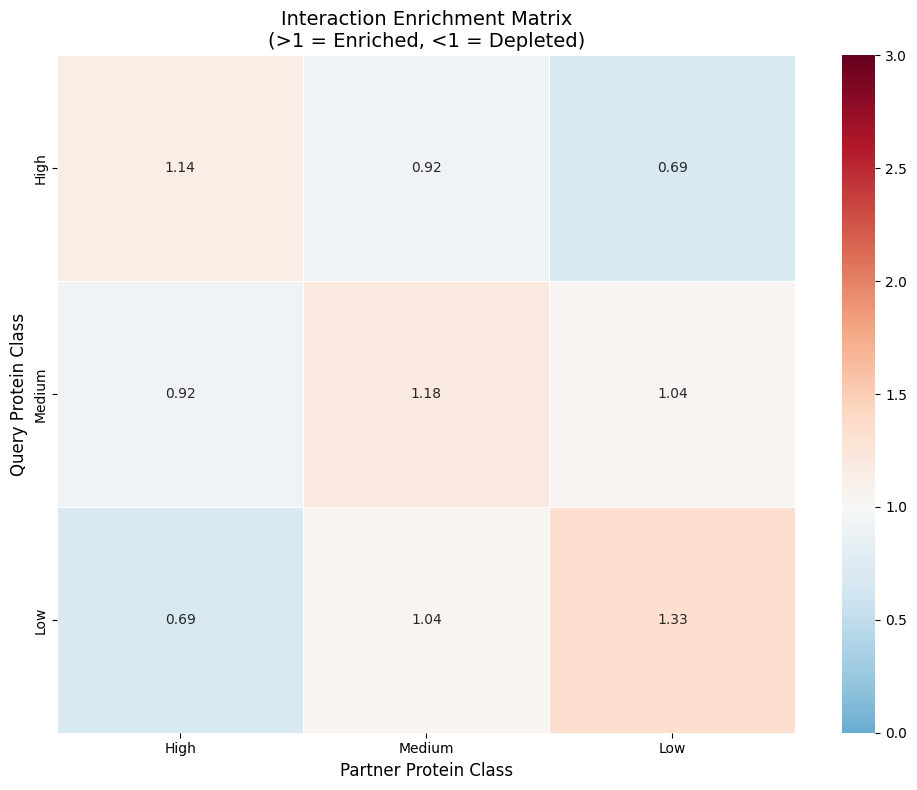


Figure saved to: pllps_interaction_matrix.png

Interpretation:
- Values > 1.0 (Red): These classes interact MORE than expected by chance.
- Values < 1.0 (Blue): These classes interact LESS than expected by chance.
- Diagonal (High-High, Med-Med, Low-Low): Shows homotypic preference.


In [17]:
# Visualize the results
lf.plot_interaction_heatmap(results)

## Subcellular Location Analysis

We will now break down the interaction patterns by subcellular location. This helps us understand if the "like-interacts-with-like" phenomenon is specific to certain compartments (e.g., Nucleus, Nucleolus) or general across the cell.

We filter both the background probabilities and the interaction network to include only proteins found in each specific location.

Re-parsing locations...
Analyzing interactions within: ['Nucleus', 'Cytoplasm', 'Cell membrane', 'Cytosol', 'Nucleolus', 'Endoplasmic reticulum', 'Stress granule', 'PML body', 'P-body', 'Nuclear speckle', 'Mitochondrion', 'Golgi apparatus', 'Lysosome', 'Peroxisome', 'Secreted']

Analyzing location: Nucleus
  Proteins in location: 5137
  Interactions within location: 75223
  Class breakdown: High=2617, Medium=812, Low=1708

GENOMIC BACKGROUND PROBABILITIES
P(High): 0.509
P(Medium): 0.158
P(Low): 0.332

INTERACTION ENRICHMENT MATRIX (Observed / Expected)
        High  Medium   Low
High    0.99    0.88  0.84
Medium  0.88    1.10  1.19
Low     0.84    1.19  1.49

Analyzing location: Cytoplasm
  Proteins in location: 5183
  Interactions within location: 57210
  Class breakdown: High=1984, Medium=810, Low=2389

GENOMIC BACKGROUND PROBABILITIES
P(High): 0.383
P(Medium): 0.156
P(Low): 0.461

INTERACTION ENRICHMENT MATRIX (Observed / Expected)
        High  Medium   Low
High    1.01    0.90  0.

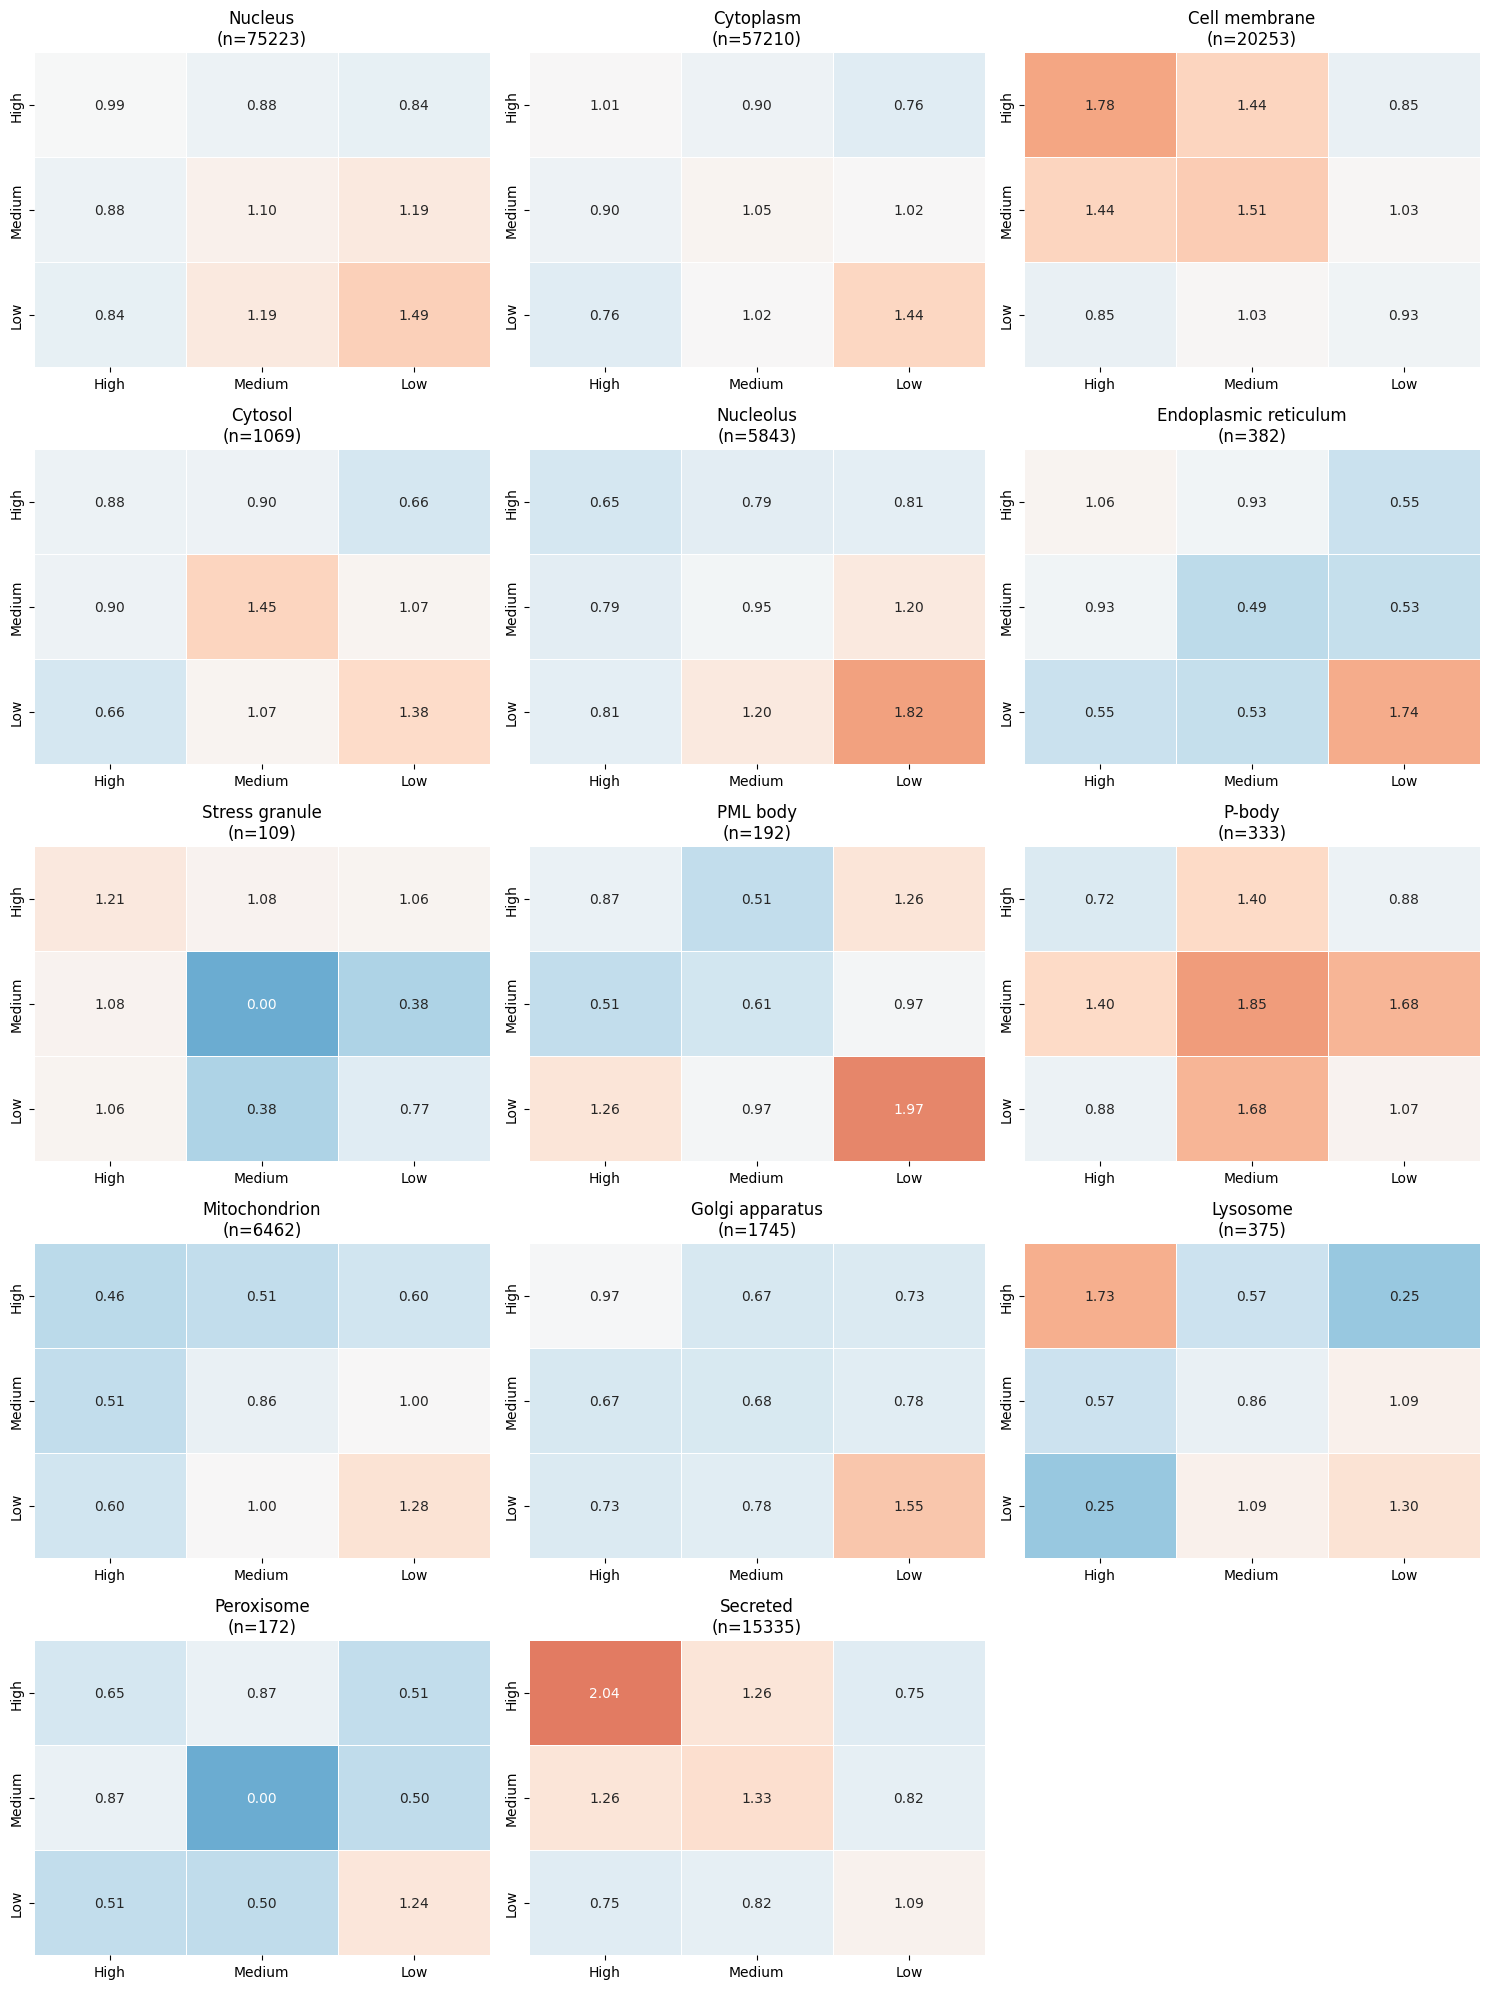

Figure saved to: pllps_location_analysis.png


In [20]:
import importlib
import interaction_analysis as ia
importlib.reload(ia)

# Re-parse locations with the fixed parser
print("Re-parsing locations...")
df = lf.add_location_columns(df)

# Define locations to analyze
locations_of_interest = [
    'Nucleus', 
    'Cytoplasm', 
    'Cell membrane', 
    'Cytosol',
    'Nucleolus',
    'Endoplasmic reticulum',
    'Stress granule',
    'PML body',
    'P-body',
    'Nuclear speckle',
    'Mitochondrion',
    'Golgi apparatus',
    'Lysosome',
    'Peroxisome',
    'Secreted'
]

print(f"Analyzing interactions within: {locations_of_interest}")

# Run location-specific analysis
location_results = lf.analyze_interactions_by_location(
    matched_df, 
    df, 
    locations_of_interest,
    high_threshold=0.7,
    low_threshold=0.4
)

# Plot results
lf.plot_location_heatmaps(location_results)